Basit Doğrusal Regresyon

In [4]:
import pandas as pd

df = pd.read_csv("../resources/student_performance.csv")

print(df.head(3))
print(df.info())


   study_hours_per_week  attendance_rate  sleep_hours_per_day  \
0                  22.0             57.0                  4.6   
1                  30.0             84.0                  4.9   
2                   8.0             64.0                  6.8   

   solved_question_count  previous_term_score  internet_usage_hours_per_day  \
0                  643.0                 66.0                           2.2   
1                  944.0                 39.0                           0.7   
2                  134.0                 60.0                           5.9   

   final_exam_score  
0              89.9  
1              96.3  
2              66.6  
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   study_hours_per_week          1976 non-null   float64
 1   attendance_rate               1964 non-null   float64
 2 

In [5]:
print(df.isnull().sum())

study_hours_per_week            24
attendance_rate                 36
sleep_hours_per_day             50
solved_question_count           30
previous_term_score             20
internet_usage_hours_per_day    44
final_exam_score                16
dtype: int64


In [7]:
df_model = df.dropna(subset =["final_exam_score"]).copy()
median_study_hours = df_model["study_hours_per_week"].median()
df_model["study_hours_per_week"] = df_model["study_hours_per_week"].fillna(median_study_hours)

print(df_model.isnull().sum())


print(df.info())
print(df_model.info())


study_hours_per_week             0
attendance_rate                 35
sleep_hours_per_day             50
solved_question_count           30
previous_term_score             20
internet_usage_hours_per_day    44
final_exam_score                 0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   study_hours_per_week          1976 non-null   float64
 1   attendance_rate               1964 non-null   float64
 2   sleep_hours_per_day           1950 non-null   float64
 3   solved_question_count         1970 non-null   float64
 4   previous_term_score           1980 non-null   float64
 5   internet_usage_hours_per_day  1956 non-null   float64
 6   final_exam_score              1984 non-null   float64
dtypes: float64(7)
memory usage: 109.5 KB
None
<class 'pandas.DataFrame'>
Index: 1984 entries, 0 to 1999
Data column

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_model[["study_hours_per_week"]]
y = df_model["final_exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


print("b1 :", float(model.coef_[0]))
print("b0 :", float(model.intercept_))

print("MSE Train :", mean_squared_error(y_train, y_pred_train))
print("MSE Test :", mean_squared_error(y_test, y_pred_test))

print("R2 Train :", r2_score(y_train, y_pred_train))
print("R2 Test :", r2_score(y_test, y_pred_test))



b1 : 0.6814415308881754
b0 : 80.111413954668
MSE Train : 71.13331611710898
MSE Test : 68.52472181226747
R2 Train : 0.3101744517929965
R2 Test : 0.3175915911594501


/Users/hamitseyrek/miniconda3/envs/statistics/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


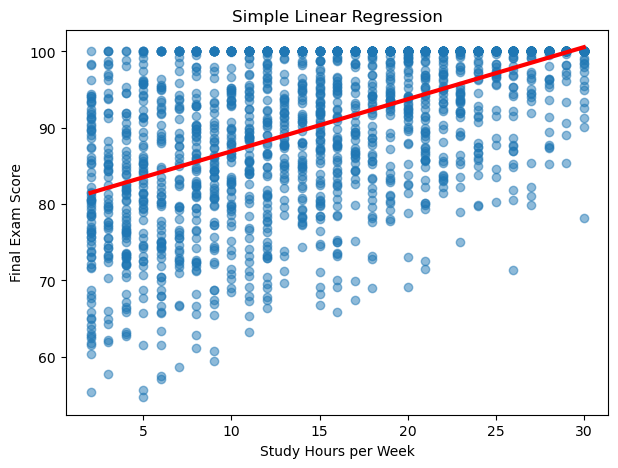

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

x_min = df_model["study_hours_per_week"].min()
x_max = df_model["study_hours_per_week"].max()
x_grid = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_grid = model.predict(x_grid)

plt.figure(figsize=(7, 5))
plt.scatter(df_model["study_hours_per_week"], df_model["final_exam_score"], alpha=0.5)
plt.plot(x_grid, y_grid, color="red", linewidth=3)
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")
plt.title("Simple Linear Regression")
plt.show()




